# Chapter 26: Well Network Optimization

This notebook demonstrates optimization of a multi-well gathering network. Four wells with
different reservoir pressures and productivity indices are connected to a common manifold.
We optimize choke settings to maximize total production while respecting manifold and
pipeline pressure constraints.

**Key Concepts:**
- Multi-well gathering network modeling
- Choke valve pressure drop and flow control
- Well inflow performance (IPR)
- Network optimization for maximum total rate

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch27_well_network.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 26.1 Define Well Fluids and Network

Each well produces gas at different reservoir conditions. We model four wells with
choke valves flowing into a common mixer (manifold), followed by a pipeline.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# --- Well parameters ---
well_data = [
    {"name": "Well A", "pres": 250.0, "temp": 90.0, "rate": 30000.0},
    {"name": "Well B", "pres": 220.0, "temp": 85.0, "rate": 25000.0},
    {"name": "Well C", "pres": 200.0, "temp": 80.0, "rate": 20000.0},
    {"name": "Well D", "pres": 180.0, "temp": 75.0, "rate": 15000.0},
]

# --- Common fluid composition ---
def create_well_fluid(temp_c, pres_bara):
    f = jneqsim.thermo.system.SystemSrkEos(273.15 + temp_c, pres_bara)
    f.addComponent("nitrogen", 0.01)
    f.addComponent("CO2", 0.015)
    f.addComponent("methane", 0.85)
    f.addComponent("ethane", 0.06)
    f.addComponent("propane", 0.03)
    f.addComponent("n-butane", 0.02)
    f.addComponent("n-pentane", 0.01)
    f.addComponent("water", 0.005)
    f.setMixingRule("classic")
    return f

# --- Build network ---
manifold_pressure = 80.0  # bara

streams = []
chokes = []
wells = []
WellFlow = jneqsim.process.equipment.reservoir.WellFlow
process = jneqsim.process.processmodel.ProcessSystem()

for wd in well_data:
    fluid = create_well_fluid(wd["temp"], wd["pres"])
    stream = jneqsim.process.equipment.stream.Stream(wd["name"], fluid)
    stream.setFlowRate(wd["rate"], "kg/hr")
    stream.setTemperature(wd["temp"], "C")
    stream.setPressure(wd["pres"], "bara")

    stream.run()
    assert _physics.run(stream, 'calculation_cell_3:stream', candidate=False)
    well = WellFlow(wd["name"] + " Inflow")
    well.setInletStream(stream)
    # Calibrate a pressure-squared inflow coefficient to the declared design rate.
    # Units: (MSm3/day)/bar2; this is an inflow-only illustration, without tubing.
    well.setWellProductionIndex(float(stream.getFlowRate("MSm3/day")) / (wd["pres"]**2 - (manifold_pressure + 10.0)**2))
    well.setOutletPressure(manifold_pressure + 10.0, "bara")
    well.solveFlowFromOutletPressure(True)
    wells.append(well)
    choke = jneqsim.process.equipment.valve.ThrottlingValve(wd["name"] + " Choke", well.getOutletStream())
    choke.setOutletPressure(manifold_pressure)

    streams.append(stream)
    chokes.append(choke)
    process.add(stream)
    process.add(well)
    process.add(choke)

# --- Mixer (manifold) ---
mixer = jneqsim.process.equipment.mixer.Mixer("Production Manifold")
for choke in chokes:
    mixer.addStream(choke.getOutletStream())

process.add(mixer)
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

total_rate = mixer.getOutletStream().getFlowRate("kg/hr")
print(f"Total production at manifold: {total_rate:.0f} kg/hr")
print(f"Manifold temperature: {mixer.getOutletStream().getTemperature('C'):.1f} °C")
print(f"Manifold pressure: {mixer.getOutletStream().getPressure('bara'):.1f} bara")

for i, wd in enumerate(well_data):
    print(f"  {wd['name']}: {streams[i].getFlowRate('kg/hr'):.0f} kg/hr, "
          f"dP choke = {wd['pres'] - manifold_pressure:.0f} bar")


Total production at manifold: 90000 kg/hr
Manifold temperature: 80.9 °C
Manifold pressure: 80.0 bara
  Well A: 30000 kg/hr, dP choke = 170 bar
  Well B: 25000 kg/hr, dP choke = 140 bar
  Well C: 20000 kg/hr, dP choke = 120 bar
  Well D: 15000 kg/hr, dP choke = 100 bar


## 26.2 Manifold Pressure Sensitivity

We sweep the manifold pressure and observe how individual well rates and total production change.
Lower manifold pressure allows more flow but increases choke erosion risk.

Figure saved: ../figures/ch27_manifold_pressure_sweep.png


ch27_well_network.ipynb:cell5:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


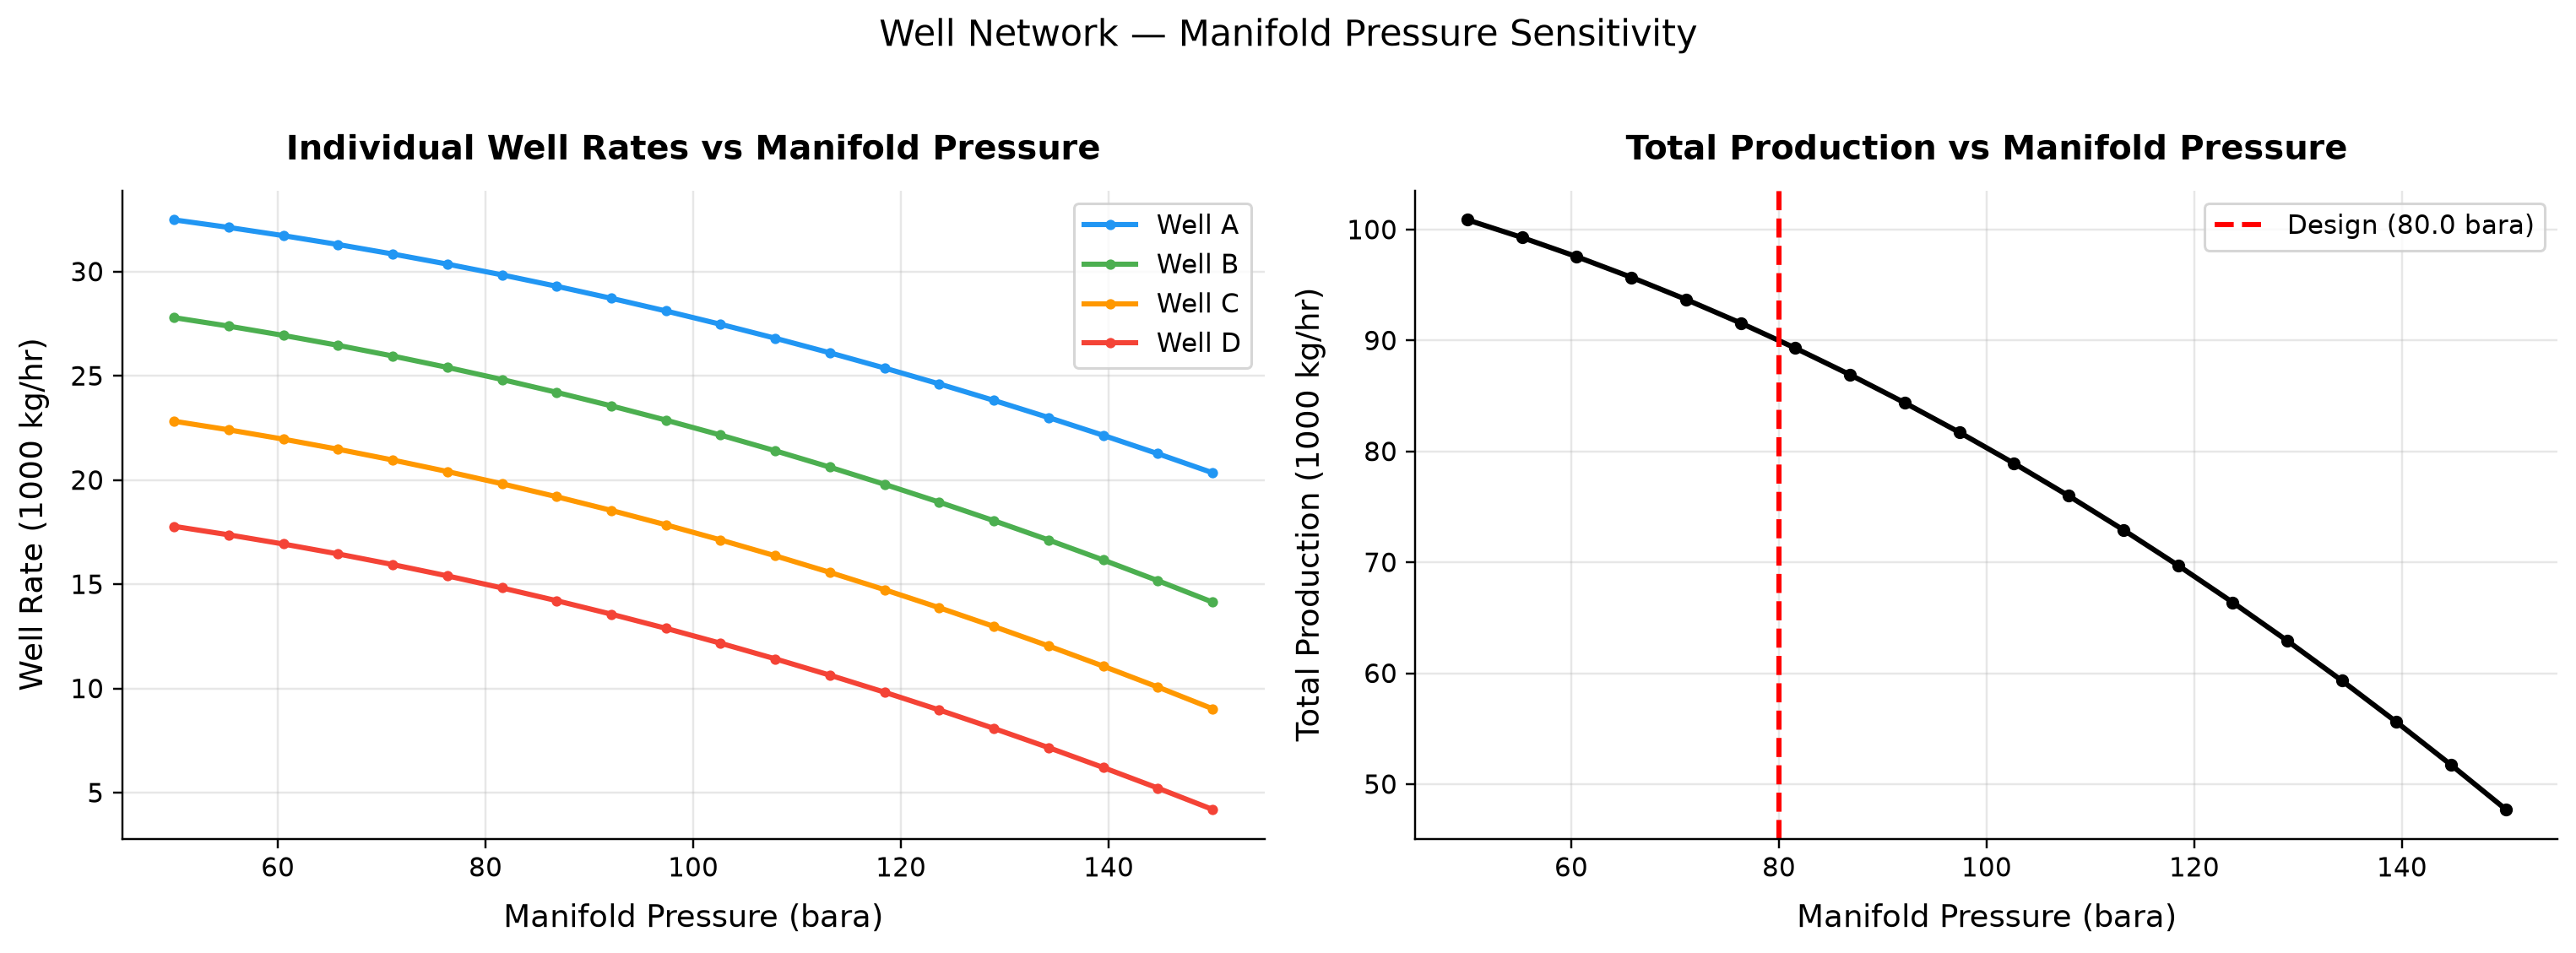

In [3]:
# --- Sweep manifold pressure ---
manifold_pressures = np.linspace(50, 150, 20)
well_rates = {wd["name"]: [] for wd in well_data}
total_rates = []

for p_man in manifold_pressures:
    for i, choke in enumerate(chokes):
        # Only set outlet pressure if below well reservoir pressure
        if p_man < well_data[i]["pres"]:
            wells[i].setOutletPressure(float(p_man + 10.0), "bara")
            choke.setOutletPressure(float(p_man))
    process.run()
    assert _physics.run(process, 'calculation_cell_5:process', candidate=False)

    total = 0
    for i, wd in enumerate(well_data):
        rate = wells[i].getOutletStream().getFlowRate("kg/hr")
        well_rates[wd["name"]].append(rate)
        total += rate
    total_rates.append(total)

# Reset
for well, choke in zip(wells, chokes):
    well.setOutletPressure(manifold_pressure + 10.0, "bara")
    choke.setOutletPressure(manifold_pressure)
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual well rates
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for i, wd in enumerate(well_data):
    ax1.plot(manifold_pressures, np.array(well_rates[wd["name"]]) / 1000,
             '-o', markersize=3, color=colors[i], label=wd["name"])

ax1.set_xlabel('Manifold Pressure (bara)', fontsize=12)
ax1.set_ylabel('Well Rate (1000 kg/hr)', fontsize=12)
ax1.set_title('Individual Well Rates vs Manifold Pressure', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Total production
ax2.plot(manifold_pressures, np.array(total_rates) / 1000, 'k-o', markersize=4, linewidth=2)
ax2.axvline(x=manifold_pressure, color='red', linestyle='--', label=f'Design ({manifold_pressure} bara)')
ax2.set_xlabel('Manifold Pressure (bara)', fontsize=12)
ax2.set_ylabel('Total Production (1000 kg/hr)', fontsize=12)
ax2.set_title('Total Production vs Manifold Pressure', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Well Network — Manifold Pressure Sensitivity', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch27_manifold_pressure_sweep.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch27_manifold_pressure_sweep.png")


**Executed-figure discussion.** Well A: well rate spans 20.35–32.48 1000 kg/hr across the plotted cases. Well B: well rate spans 14.14–27.79 1000 kg/hr across the plotted cases.

The NeqSim WellFlow pressure-squared inflow relation reduces the drawdown available to each well as manifold pressure rises. This is an inflow-only gathering illustration, with no tubing hydraulics or reservoir depletion. Calibrate well productivity and add tubing and shared-header losses before scheduling field production.


## 26.3 Additional choke pressure-loss sensitivity

We simulate the effect of partially closing each well's choke (reducing its outlet pressure
further) to understand how individual well choke adjustments affect the total network rate.

Figure saved: ../figures/ch27_choke_sensitivity.png


ch27_well_network.ipynb:cell7:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


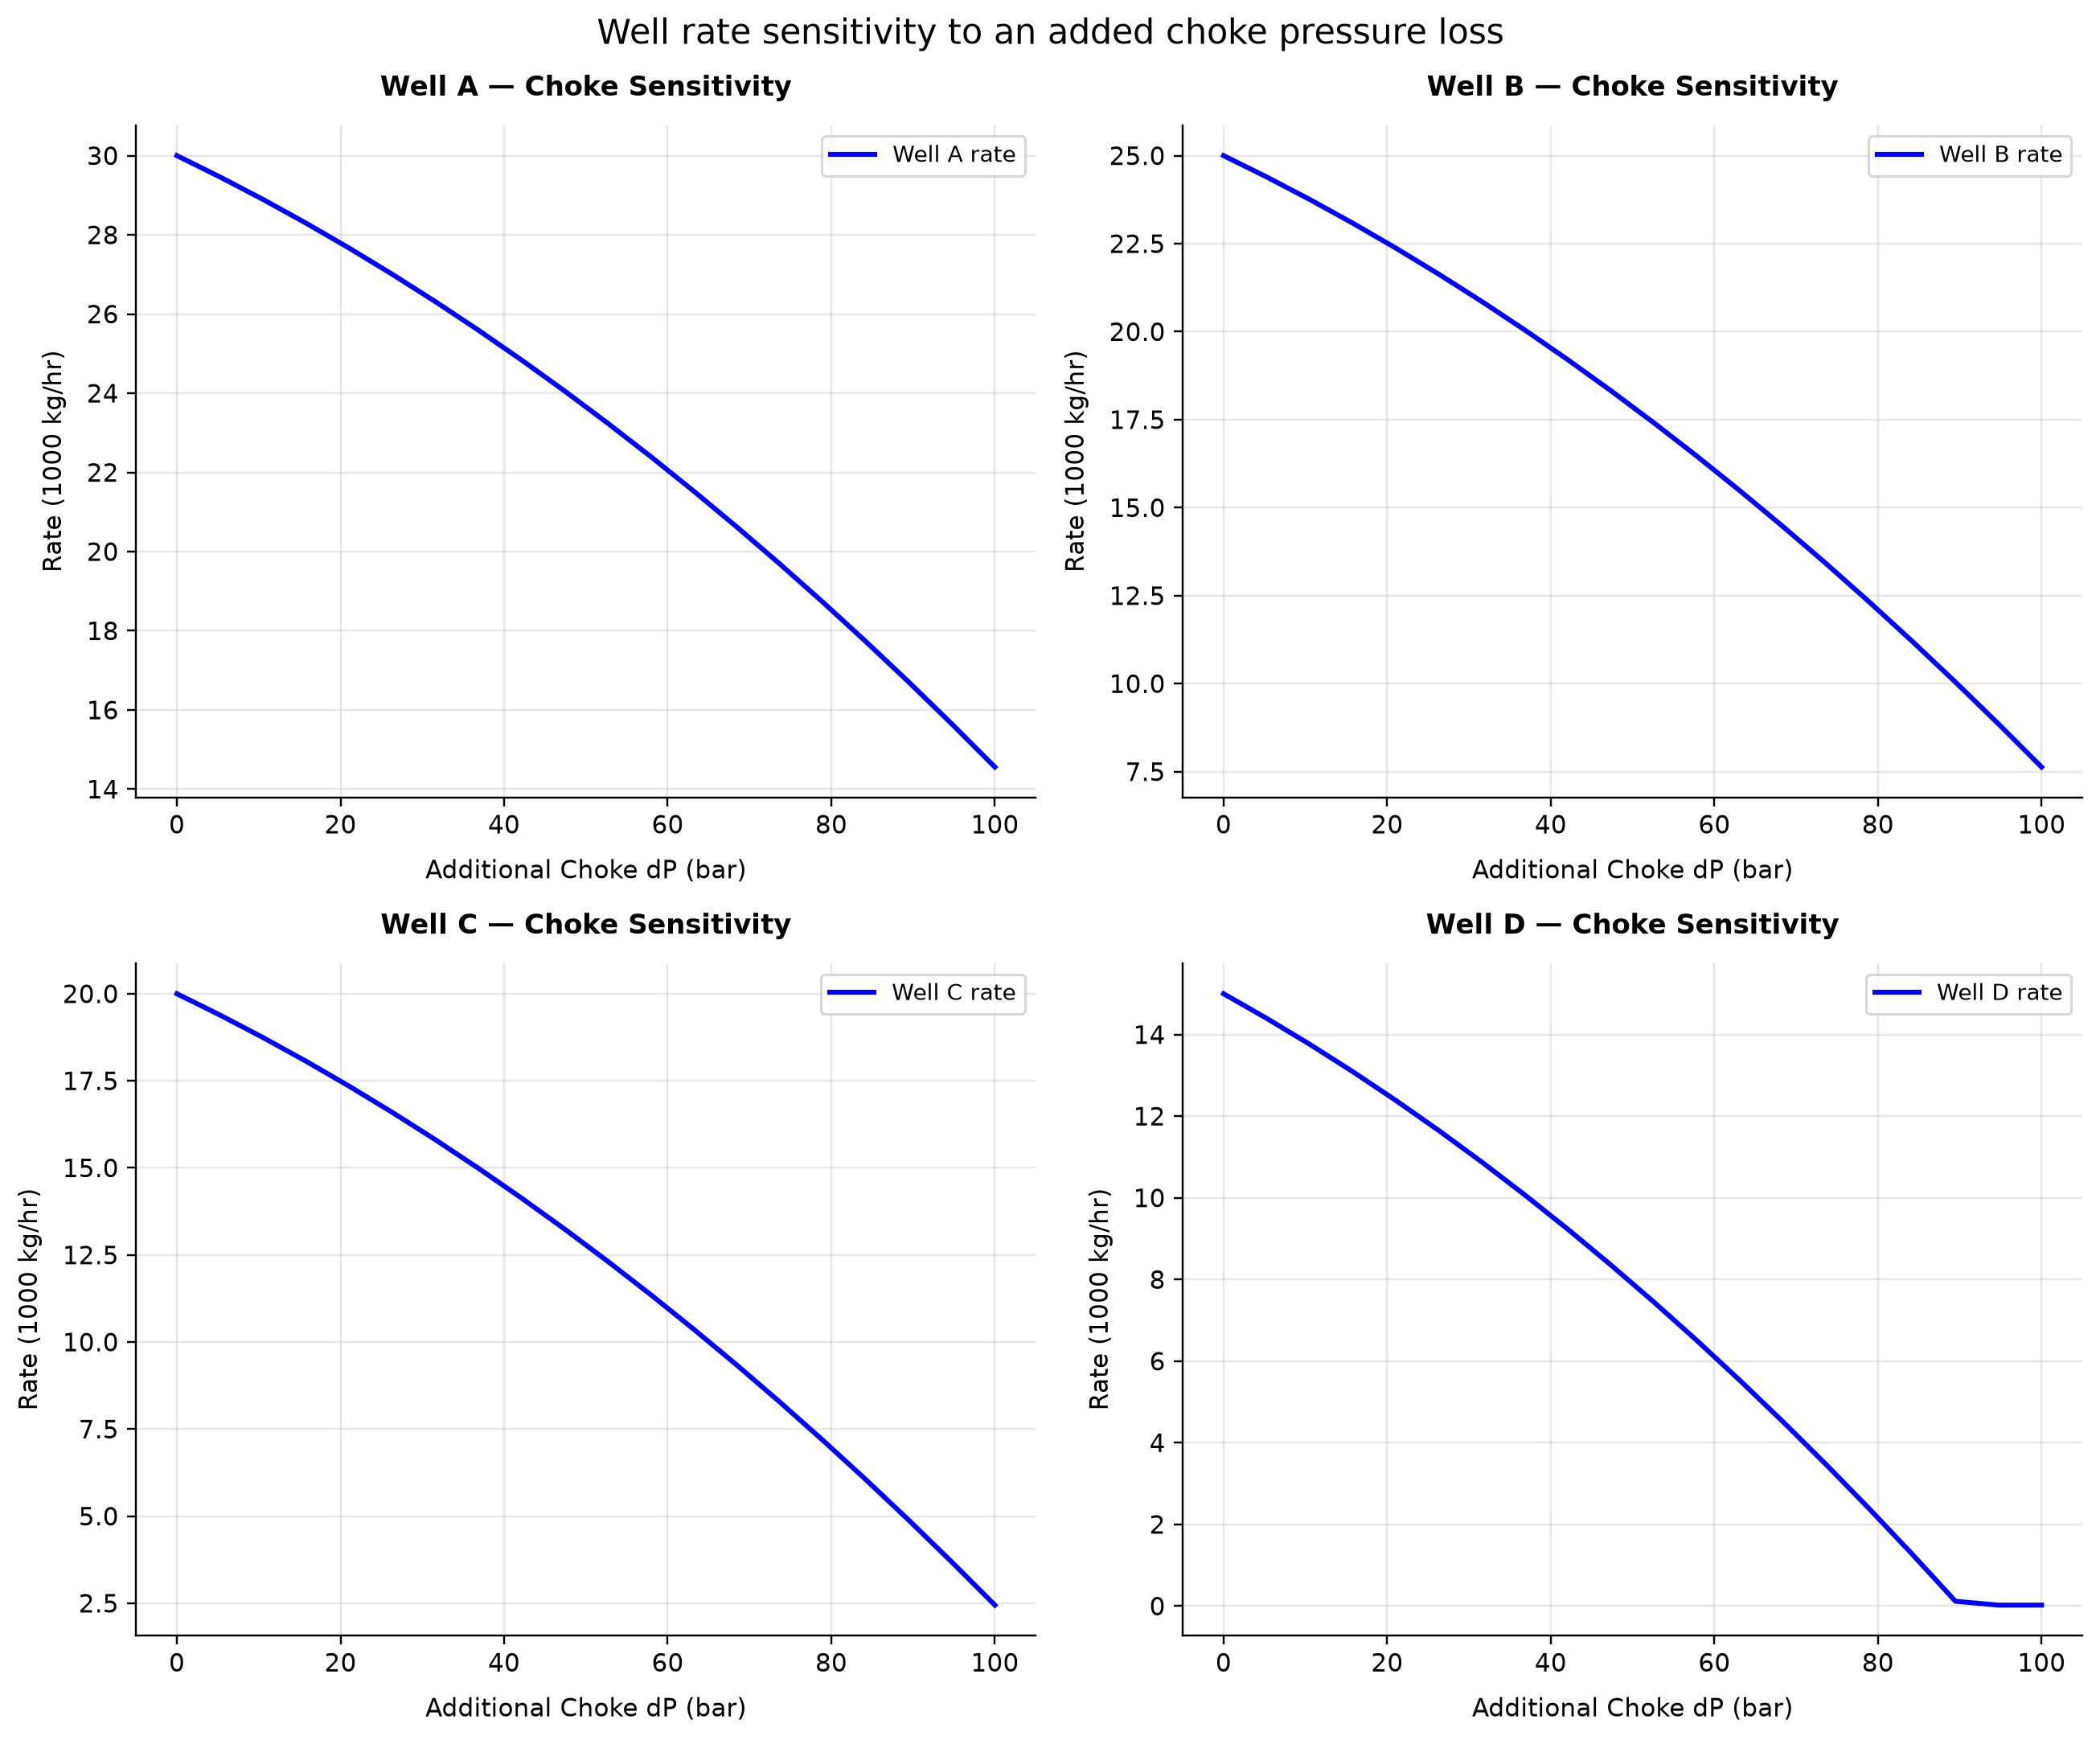

In [4]:
# --- Choke sensitivity: vary one well's choke while others remain at design ---
choke_dp_range = np.linspace(0, 100, 20)  # additional dP beyond base

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (wd, choke, stream, ax) in enumerate(zip(well_data, chokes, streams, axes.flat)):
    rates_this_well = []
    rates_total = []

    for dp_extra in choke_dp_range:
        p_out = manifold_pressure
        if p_out < 10.0:  # minimum pressure
            p_out = 10.0
        wells[idx].setOutletPressure(float(min(manifold_pressure + 10.0 + dp_extra, wd["pres"] - 0.1)), "bara")
        choke.setOutletPressure(float(p_out))
        process.run()
        assert _physics.run(process, 'calculation_cell_7:process', candidate=False)
        rates_this_well.append(wells[idx].getOutletStream().getFlowRate("kg/hr"))
        rates_total.append(mixer.getOutletStream().getFlowRate("kg/hr"))

    # Reset well drawdown and choke
    wells[idx].setOutletPressure(manifold_pressure + 10.0, "bara")
    choke.setOutletPressure(manifold_pressure)

    ax.plot(choke_dp_range, np.array(rates_this_well) / 1000, 'b-', linewidth=2, label=f'{wd["name"]} rate')
    ax.set_xlabel('Additional Choke dP (bar)', fontsize=10)
    ax.set_ylabel('Rate (1000 kg/hr)', fontsize=10)
    ax.set_title(f'{wd["name"]} — Choke Sensitivity', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

process.run()  # final reset
assert _physics.run(process, 'calculation_cell_7:process', candidate=False)

plt.suptitle('Well rate sensitivity to an added choke pressure loss', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch27_choke_sensitivity.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch27_choke_sensitivity.png")


**Executed-figure discussion.** Well A rate: rate spans 14.56–30 1000 kg/hr across the plotted cases. Well B rate: rate spans 7.63–25 1000 kg/hr across the plotted cases.

An assumed additional choke-pressure loss raises the outlet-pressure boundary seen by the selected well inflow model. Wells with lower reservoir pressure lose a larger fraction of deliverability for the same extra pressure loss. Evaluate the weakest-pressure wells first when allocating manifold backpressure.


## 26.4 Summary

Well network optimization in NeqSim demonstrates:

1. **Individual well rates** follow the pressure-squared inflow relationship and the imposed choke loss valve
2. **Manifold pressure** directly affects total production — lower pressure increases flow but may cause operational issues
3. **Wells with higher reservoir pressure** contribute more flow and have greater choke flexibility
4. **Network optimization** balances individual well constraints against total production targets

In practice, real-time optimization of choke settings is a key activity for production engineers,
especially when coupled with well test data and decline curve analysis.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [5]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                          Figure  Panel             Series                 Output / unit  Minimum  Maximum  Finite points  Missing points
ch27_manifold_pressure_sweep.png      1             Well A        Well Rate (1000 kg/hr)  20.3493  32.4816             20               0
ch27_manifold_pressure_sweep.png      1             Well B        Well Rate (1000 kg/hr)  14.1439  27.7916             20               0
ch27_manifold_pressure_sweep.png      1             Well C        Well Rate (1000 kg/hr)  9.02821  22.8213             20               0
ch27_manifold_pressure_sweep.png      1             Well D        Well Rate (1000 kg/hr)  4.19753  17.7778             20               0
ch27_manifold_pressure_sweep.png      2            Curve 1 Total Production (1000 kg/hr)  47.7189  100.872             20               0
ch27_manifold_pressure_sweep.png      2 Design (80.0 bara) Total Production (1000 kg/hr)        0        1              2               0
      ch27_choke_sensitivity.png  

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [6]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 820 distinct checks, 30925 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Network stream conservation and bounded rate response. No independent multiwell production history; well response and boundary conditions are illustrative.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
